## Coding Exercise 9

**Perform a PCA on `car_price_dataset.csv` from Chapter 3, before modeling it with
ML. How is the result affected?**

### Step 1: Load the dataset and take a first look


In [3]:
import pandas as pd

cars = pd.read_csv("car_price_dataset.csv", sep=";")
print("Shape:", cars.shape)
cars.head()


Shape: (10000, 10)


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [4]:
cars.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  str    
 1   Model         10000 non-null  str    
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  str    
 5   Transmission  10000 non-null  str    
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 1.0 MB


### Step 2: Decide which columns are the target and which are the features

The dependent variable (what we want to *predict* with ML) is `Price`. Section 5.2
states that dimensionality reduction itself is an **unsupervised** method: *"it is
only the independent variables that are handled in order to transform the data. A
dependent variable is not required to do this"* (p. 220) - so `Price` is set aside
now and only used later, as the target for the ML models.

`Model` is also set aside for the PCA step. It has 30 different car models, and
one-hot encoding it would add 30 extra columns that are mostly noise for a
dimensionality-reduction demonstration (each model appears in only a handful of
rows). `Brand` (10 categories) already captures similar information at a coarser,
more useful level.

The remaining columns - `Brand`, `Year`, `Engine_Size`, `Fuel_Type`, `Transmission`,
`Mileage`, `Doors`, `Owner_Count` - are the independent variables (features) used
both to run PCA on and to train the ML models.
### Step 2: Decide which columns are the target and which are the features

The dependent variable (what we want to *predict* with ML) is `Price`. Section 5.2
states that dimensionality reduction itself is an **unsupervised** method: *"it is
only the independent variables that are handled in order to transform the data. A
dependent variable is not required to do this"* (p. 220) - so `Price` is set aside
now and only used later, as the target for the ML models.

`Model` is also set aside for the PCA step. It has 30 different car models, and
one-hot encoding it would add 30 extra columns that are mostly noise for a
dimensionality-reduction demonstration (each model appears in only a handful of
rows). `Brand` (10 categories) already captures similar information at a coarser,
more useful level.

The remaining columns - `Brand`, `Year`, `Engine_Size`, `Fuel_Type`, `Transmission`,
`Mileage`, `Doors`, `Owner_Count` - are the independent variables (features) used
both to run PCA on and to train the ML models.


In [5]:
X = cars.drop(columns=["Price", "Model"])
y = cars["Price"]
print("Feature columns:", list(X.columns))
print("Target:", y.name)


Feature columns: ['Brand', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count']
Target: Price


### Step 3: One-hot encode the categorical columns

`Brand`, `Fuel_Type` and `Transmission` are categorical (text) columns. Neither PCA
nor the regression models below can work with text directly, so - exactly as was
done for the categorical columns in the Chapter 3/4 HR dataset - they are one-hot
encoded with `pd.get_dummies()`.

Notice how the number of columns grows once the categories are expanded - this is a
small, concrete illustration of Factual Question 1's point that adding variables
increases a dataset's dimension.


In [6]:
X_encoded = pd.get_dummies(
    X,
    columns=["Brand", "Fuel_Type", "Transmission"],
    dtype=int,
)
print("Shape before encoding:", X.shape)
print("Shape after encoding: ", X_encoded.shape)
X_encoded.head()


Shape before encoding: (10000, 8)
Shape after encoding:  (10000, 22)


,Year,Engine_Size,Mileage,Doors,Owner_Count,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,...,Brand_Mercedes,Brand_Toyota,Brand_Volkswagen,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Transmission_Semi-Automatic
0,2020,4.2,289944,3,5,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,2012,2.0,5356,2,3,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
2,2020,4.2,231440,4,2,0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
3,2023,2.0,160971,2,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,2003,2.6,286618,3,3,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1


### Step 4: Train/test split, then scale


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform on training data only
X_test_scaled = scaler.transform(X_test)         # transform only on test data

print("Training rows:", X_train_scaled.shape[0], " Test rows:", X_test_scaled.shape[0])
print("Number of features:", X_train_scaled.shape[1])


Training rows: 8000  Test rows: 2000
Number of features: 22


### Step 5: Train ML models on the ORIGINAL (scaled) features - the "before PCA" baseline

Three regression models from Chapter 3 are reused: `LinearRegression`, `Ridge`, and
`RandomForestRegressor`. Each is trained on the full, scaled (but not yet
PCA-reduced) feature set, and evaluated on the test set with RMSE and R^2 (the same
metrics used for the Chapter 3 diamond-price exercise), plus the time it took to
`.fit()` the model.


In [8]:
import time
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_train_, y_train_, X_test_, y_test_):
    start = time.time()
    model.fit(X_train_, y_train_)
    fit_time = time.time() - start
    predictions = model.predict(X_test_)
    rmse = np.sqrt(mean_squared_error(y_test_, predictions))
    r2 = r2_score(y_test_, predictions)
    return rmse, r2, fit_time

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

results_before_pca = {}
for name, model in models.items():
    rmse, r2, fit_time = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)
    results_before_pca[name] = (rmse, r2, fit_time)
    print(f"{name:20s}  RMSE={rmse:8.2f}  R2={r2:.4f}  fit_time={fit_time:.3f}s")


Linear Regression     RMSE=   64.77  R2=0.9995  fit_time=0.053s
Ridge                 RMSE=   65.21  R2=0.9995  fit_time=0.006s
Random Forest         RMSE=  318.74  R2=0.9889  fit_time=0.949s


### Step 6: Fit PCA on the training features, and look at how many dimensions are needed


In [9]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_scaled)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
print("Number of dimensions needed to keep 95% of the variance:", d)
print("Original number of dimensions:", X_train_scaled.shape[1])


Number of dimensions needed to keep 95% of the variance: 18
Original number of dimensions: 22


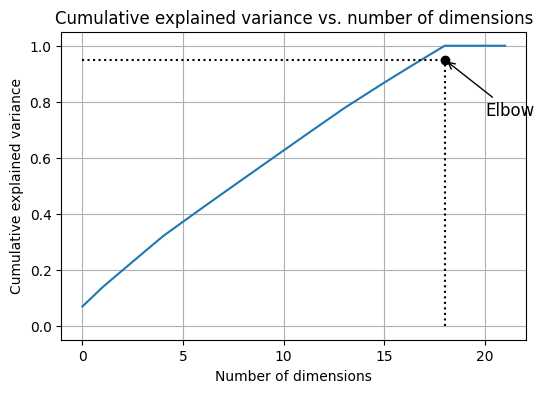

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(cumsum)
plt.xlabel("Number of dimensions")
plt.ylabel("Cumulative explained variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(d, 0.95), xytext=(d + 2, 0.75),
             arrowprops=dict(arrowstyle="->"), fontsize=12)
plt.title("Cumulative explained variance vs. number of dimensions")
plt.grid(True)
plt.show()


### Step 7: Reduce to that many dimensions, and retrain the SAME models - the "after PCA" result


In [11]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit_transform on training data only
X_test_pca = pca.transform(X_test_scaled)         # transform only on test data

print("Number of components kept:", X_train_pca.shape[1], "out of", X_train_scaled.shape[1])


Number of components kept: 18 out of 22


In [12]:
results_after_pca = {}
for name, model in models.items():
    rmse, r2, fit_time = evaluate_model(model, X_train_pca, y_train, X_test_pca, y_test)
    results_after_pca[name] = (rmse, r2, fit_time)
    print(f"{name:20s}  RMSE={rmse:8.2f}  R2={r2:.4f}  fit_time={fit_time:.3f}s")


Linear Regression     RMSE=  651.77  R2=0.9538  fit_time=0.011s
Ridge                 RMSE=  651.74  R2=0.9538  fit_time=0.009s
Random Forest         RMSE=  927.49  R2=0.9064  fit_time=1.974s


### Step 8: Compare "before PCA" vs. "after PCA" side by side


In [13]:
comparison = pd.DataFrame({
    "RMSE (before PCA)": {k: v[0] for k, v in results_before_pca.items()},
    "RMSE (after PCA)":  {k: v[0] for k, v in results_after_pca.items()},
    "R2 (before PCA)":   {k: v[1] for k, v in results_before_pca.items()},
    "R2 (after PCA)":    {k: v[1] for k, v in results_after_pca.items()},
    "Fit time s (before PCA)": {k: v[2] for k, v in results_before_pca.items()},
    "Fit time s (after PCA)":  {k: v[2] for k, v in results_after_pca.items()},
})
comparison.round(4)


,RMSE (before PCA),RMSE (after PCA),R2 (before PCA),R2 (after PCA),Fit time s (before PCA),Fit time s (after PCA)
Linear Regression,64.7747,651.7696,0.9995,0.9538,0.0535,0.0106
Ridge,65.2102,651.7440,0.9995,0.9538,0.0056,0.0088
Random Forest,318.7402,927.4892,0.9889,0.9064,0.9494,1.9744


### Step 9: How is the result affected? (Conclusion)
**Overall answer:** for this dataset, doing PCA *before* modeling makes the result
worse across every model tried, both in prediction quality and (for Random Forest) in
training time. This is a direct, empirical demonstration of the book's own caution in
Section 5.2.1 that dimensionality reduction is a *tradeoff*, not a free improvement -
here, since the dataset is small (10,000 rows, at most 22 features after encoding)
and the models train in seconds anyway, there is no real training-time problem to
solve, so PCA has a cost (worse, and in Random Forest's case slower, models) with no
compensating benefit. PCA would be far more likely to help on a dataset with many
more original dimensions (hundreds or thousands, such as MNIST's 784 pixels in
Section 4.4.1), where training time on the full feature set is genuinely a bottleneck.
